In [ ]:
import gc
import itertools
import math
import os
import random
import sys
from collections import Counter, defaultdict
from copy import deepcopy
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias

import einops
import numpy as np
import pandas as pd
import torch as t
from datasets import load_dataset
from IPython.display import clear_output, display
from jaxtyping import Float, Int
from rich import print as rprint
from rich.table import Table

from transformer_lens import HookedTransformer, HookedTransformerConfig
from tabulate import tabulate
from torch import Tensor, nn
from torch.nn import functional as F
from tqdm.auto import tqdm
from transformer_lens import ActivationCache, loading_from_pretrained
from transformer_lens.hook_points import HookPoint
from transformer_lens.utils import get_act_name, to_numpy

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from scipy.sparse import csr_array
from scipy.sparse.csgraph import maximum_bipartite_matching, min_weight_full_bipartite_matching

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

## Adam vs AdamW - Performance Parity

In [ ]:
import importlib
import pandas as pd
import torch

# Set architecture (without "_wd")"
arch = "gpt2"
arch_list = [f"{arch}", f"{arch}_wd"]

# Constants
chkpt_file = "final.pt"
shard = 9
epoch = 1
print(f"Using checkpoint: {chkpt_file}")

SCRATCH = "Path to root directory"

SEEDS = [i for i in range(1,51)]
if "gpt2" in arch:
    SEEDS = [i for i in range(1,6)]  # only 5 seeds for gpt2

# Validation dataset
split = "test"
dataset_variant = "wikitext-2-raw-v1"
ds = load_dataset("wikitext", dataset_variant, split=split)

def load_named_config(module_name: str, config_name: str) -> dict:
    try:
        mod = importlib.import_module(module_name)
    except Exception as e:
        raise ImportError(f"Could not import config module '{module_name}': {e}") from e

    if not hasattr(mod, "CONFIGS"):
        raise AttributeError(f"Module '{module_name}' does not define CONFIGS.")

    CONFIGS = getattr(mod, "CONFIGS")
    if config_name not in CONFIGS:
        available = ", ".join(sorted(CONFIGS.keys()))
        raise KeyError(f"Config '{config_name}' not found in {module_name}. Available: {available}")

    return dict(CONFIGS[config_name])  # copy so we can tweak

# (wikitext_perplexity function expected to be defined below in this same cell)
from typing import Optional
import math
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformer_lens import HookedTransformer

def _pick_device(device: Optional[str]) -> str:
    return device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def wikitext_perplexity(
    model_name: Optional[str] = None,
    model: Optional[HookedTransformer] = None,
    dataset_variant: str = "wikitext-2-raw-v1",
    split: str = "test",
    device: Optional[str] = None,
    prepend_bos: bool = True,
    block_size: Optional[int] = None,
    max_examples: Optional[int] = None,
    ds: Optional[object] = None
) -> float:
    assert (model_name is None) ^ (model is None), "Provide exactly one of `model_name` or `model`."

    #ds = load_dataset("wikitext", dataset_variant, split=split)
    texts = ds["text"]
    if max_examples is not None:
        texts = texts[:max_examples]
    raw_text = "\n\n".join(texts)

    #if model is None:
    #    model = HookedTransformer.from_pretrained(model_name)
    model.eval()
    device = _pick_device(device)
    model.to(device)

    toks = model.to_tokens(raw_text, prepend_bos=prepend_bos).squeeze(0).to("cpu")
    N = toks.numel()
    if N < 2:
        raise ValueError("Tokenized corpus is too short to compute perplexity.")

    if block_size is None:
        block_size = model.cfg.n_ctx
    block_size = int(block_size)
    assert block_size >= 2, "block_size (context length) must be at least 2."

    stride = block_size - 1
    total_nll = 0.0
    total_tokens = 0

    for start in range(0, N - 1, stride):
        end = min(start + block_size, N)
        window = toks[start:end]
        window = window.to(device)
        logits = model(window.unsqueeze(0))
        targets = window[1:]
        pred_logits = logits[0, :-1, :]

        nll = F.cross_entropy(pred_logits, targets, reduction="sum")
        total_nll += float(nll.item())
        total_tokens += targets.numel()

    mean_nll = total_nll / max(total_tokens, 1)
    ppl = float(math.exp(mean_nll))
    return ppl

# Run: build/load models for each arch and compute perplexity, storing results in a DataFrame
results = []
for arch in arch_list:
    print(f"Processing arch: {arch}")
    cfg_dict = load_named_config("model_configs", arch)

    # Build HookedTransformerConfig for this arch
    cfg = HookedTransformerConfig(
        n_layers=cfg_dict["n_layers"],
        d_model=cfg_dict["d_model"],
        n_heads=cfg_dict["n_heads"],
        d_head=cfg_dict["d_head"],
        d_mlp=cfg_dict.get("d_mlp", None),
        n_ctx=cfg_dict["n_ctx"],
        act_fn=cfg_dict.get("act_fn", "gelu"),
        d_vocab=cfg_dict["d_vocab"],
        init_weights=True,
        tokenizer_name=cfg_dict["tokenizer_name"],
        model_name=cfg_dict.get("model_name", arch),
        attn_only=cfg_dict.get("attn_only", False),
    )

    # Constants
    SCRATCH = "Path to root directory"
    chkpt_dir = SCRATCH + "chkpts/" + arch
    NUM_LAYERS = cfg.n_layers
    NUM_HEADS = cfg.n_heads
    ATTN_ONLY = cfg.attn_only
    chkpt_file = "final.pt"
    shard = 9
    epoch = 1

    # instantiate models (one per seed)
    models = []
    for SEED in SEEDS:
        cfg.seed = SEED
        cfg.init_weights = True
        model = HookedTransformer(cfg)
        models.append(model)

    for ind, SEED in enumerate(SEEDS):
        if (arch == "gpt2") or (arch == "gpt2_wd"):
            model_state_dict = t.load(chkpt_dir + f"/gpt2_seed{SEED}_shard{shard}_epoch{epoch}_owt/{chkpt_file}")
            models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)
        else:
            if ATTN_ONLY:
                model_state_dict = t.load(
                    chkpt_dir + f"/causal_attn_only_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
                )
                models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

            else:
                model_state_dict = t.load(
                    chkpt_dir + f"/causal_attn_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
                )
                print(f"Loading model for seed {SEED} from {chkpt_dir}/causal_attn_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}")
                models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

        # compute perplexity (uses device selection inside the function)
        ppl = wikitext_perplexity(model=models[ind], ds=ds)
        results.append({
            "arch": arch,
            "seed": SEED,
            "epoch": epoch,
            "chkpt_file": chkpt_file,
            "perplexity": ppl
        })
        print(f"  -> seed {SEED} PPL: {ppl:.3f}")

df = pd.DataFrame(results)


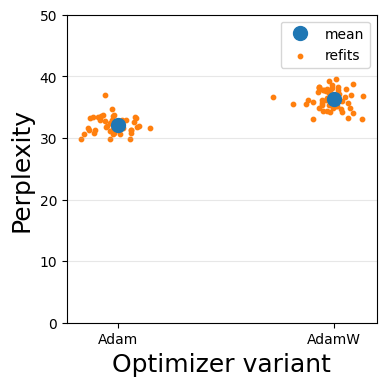

In [5]:
# plot mean and overlay scatter of individual seed points
stats = df.groupby("arch")["perplexity"].agg(["mean", "std"]).reset_index()
x = np.arange(len(stats))
means = stats["mean"].values

plt.figure(figsize=(4, 4))
plt.plot(x, means, 'o', color='C0', markersize=10, label='mean')

# scatter individual points with a small horizontal jitter
for i, arch in enumerate(stats["arch"]):
    ys = df.loc[df["arch"] == arch, "perplexity"].values
    xs = np.random.normal(loc=i, scale=0.07, size=len(ys))
    plt.scatter(xs, ys, color='C1', zorder=1, s=10, label='_nolegend_' if i > 0 else 'refits')

plt.xticks(x, ["Adam","AdamW"])
plt.xlabel("Optimizer variant", fontsize=18)
plt.ylabel("Perplexity", fontsize=18)
#plt.title(f"Perplexity for {NUM_LAYERS}-layer {NUM_HEADS}-head {ATTN_ONLY and 'Attention-Only' or 'MLP'} instances trained with Adam vs AdamW")
plt.legend()
plt.ylim(bottom=0, top=50)
plt.grid(axis='y', alpha=0.3)
plt.show()
